In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from libpysal import weights
import seaborn as sns
from esda import Moran_Local
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from esda import Moran

from splot.esda import plot_local_autocorrelation

import warnings
warnings.filterwarnings('ignore')

c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Municipios_Antioquia.shp")
#gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Subzonas_Antioquia.shp")
#gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Subzonas_Extension_Antioquia.shp")
print(gdf.crs)
gdf=gdf.to_crs(9377)
gdf["Gradiente"]=gdf["Elev_max"]-gdf["Elev_min"]
gdf.head()

EPSG:4326


,OBJECTID_1,NOMBRE_ENT,CATEGORIA,DEPARTAMEN,COD_DEPART,COD_MUNICI,AREA_KM,OBSERVACIO,PK_CUE,ACTO_ADMIN,...,TPI_std,TPI_cv,Curv_std,Curv_cv,Pend_std,Pend_cv,Elev_std,Elev_cv,geometry,Gradiente
0,4267.0,YARUMAL,M,ANTIOQUIA,05,887,717.285352,None,NaN,None,...,2.504917,1302.269109,0.985391,1649.239133,18.299343,0.553453,571.171727,0.270422,"POLYGON ((4743940.403 2358750.457, 4743981.286...",2436.510071
1,4306.0,ANGOSTURA,M,ANTIOQUIA,05,038,329.457055,None,NaN,None,...,2.422017,1071.740520,0.926558,1166.526582,13.356039,0.472276,407.187806,0.199472,"POLYGON ((4749719.317 2328295.672, 4749829.212...",1618.769897
2,4536.0,NARIÑO,M,ANTIOQUIA,05,483,314.940324,None,501785.0,None,...,3.471513,-155.312073,1.353369,-192.803303,22.404906,0.420936,614.566000,0.384461,"POLYGON ((4753055.007 2185677.515, 4753117.194...",2885.710022
3,4571.0,CARAMANTA,M,ANTIOQUIA,05,145,90.521818,None,501752.0,None,...,3.015808,380.332995,1.181636,426.117632,19.547508,0.417466,591.767063,0.331119,"POLYGON ((4714219.049 2178023.849, 4714218.052...",2501.120056
4,4579.0,SANTA ROSA DE OSOS,M,ANTIOQUIA,05,686,861.242001,None,502270.0,None,...,2.248501,-1334.154124,0.853320,-1660.639540,12.810342,0.550760,338.358861,0.139148,"POLYGON ((4715376.035 2317989.735, 4715431.894...",1885.729980


In [4]:
import numpy as np
# import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from libpysal import weights
from esda import Moran


# =====================================================
# FUNCIÓN DE MÉTRICAS
# =====================================================
def metricas_statsmodels(modelo, y_obs, y_pred, n_variables):

    y_obs = np.asarray(y_obs, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()

    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
    mae = mean_absolute_error(y_obs, y_pred)
    r2 = r2_score(y_obs, y_pred)

    n = len(y_obs)

    r2_ajustado = (
        1 - (1 - r2) * (n - 1) / (n - n_variables - 1)
        if n > n_variables + 1
        else np.nan
    )

    print(f"RMSE          : {rmse:.4f}")
    print(f"MAE           : {mae:.4f}")
    print(f"R²            : {r2:.4f}")
    print(f"R² ajustado   : {r2_ajustado:.4f}")

    if hasattr(modelo, "aic"):
        print(f"AIC           : {modelo.aic:.2f}")

    if hasattr(modelo, "bic"):
        try:
            print(f"BIC           : {modelo.bic:.2f}")
        except Exception:
            pass

    if hasattr(modelo, "deviance"):
        print(f"Deviance      : {modelo.deviance:.4f}")

    if hasattr(modelo, "pearson_chi2"):
        print(f"Pearson chi²  : {modelo.pearson_chi2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "R2_ajustado": r2_ajustado
    }


# =====================================================
# FUNCIÓN DE GRÁFICAS
# =====================================================
def graficas_statsmodels(
    gdf,
    indices,
    y_obs,
    y_pred,
    nombre_modelo="Modelo",
    matriz="queen"
):

    gdf_resultado = gdf.copy()

    y_obs = np.asarray(y_obs, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()

    gdf_resultado["Observado"] = np.nan
    gdf_resultado["Predicho"] = np.nan
    gdf_resultado["Residuo"] = np.nan
    gdf_resultado["Residuo_abs"] = np.nan

    gdf_resultado.loc[indices, "Observado"] = y_obs
    gdf_resultado.loc[indices, "Predicho"] = y_pred
    gdf_resultado.loc[indices, "Residuo"] = y_obs - y_pred
    gdf_resultado.loc[indices, "Residuo_abs"] = np.abs(y_obs - y_pred)

    # =================================================
    # MAPAS
    # =================================================
    fig, ax = plt.subplots(1, 3, figsize=(20, 7), dpi=150)

    vmin = min(
        gdf_resultado.loc[indices, "Observado"].min(),
        gdf_resultado.loc[indices, "Predicho"].min()
    )

    vmax = max(
        gdf_resultado.loc[indices, "Observado"].max(),
        gdf_resultado.loc[indices, "Predicho"].max()
    )

    gdf_resultado.plot(
        column="Observado",
        cmap="viridis",
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        ax=ax[0]
    )

    ax[0].set_title("Observado")
    ax[0].set_axis_off()

    gdf_resultado.plot(
        column="Predicho",
        cmap="viridis",
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        ax=ax[1]
    )

    ax[1].set_title("Predicho")
    ax[1].set_axis_off()

    vmax_resid = np.nanmax(
        np.abs(gdf_resultado.loc[indices, "Residuo"])
    )

    gdf_resultado.plot(
        column="Residuo",
        cmap="RdBu_r",
        vmin=-vmax_resid,
        vmax=vmax_resid,
        legend=True,
        edgecolor="black",
        linewidth=0.2,
        ax=ax[2]
    )

    ax[2].set_title("Residuos")
    ax[2].set_axis_off()

    fig.suptitle(nombre_modelo, fontsize=17, fontweight="bold")

    plt.tight_layout()
    plt.show()

    # =================================================
    # OBSERVADO VS PREDICHO
    # =================================================
    fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

    ax.scatter(
        y_obs,
        y_pred,
        s=35,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3
    )

    minimo = min(y_obs.min(), y_pred.min())
    maximo = max(y_obs.max(), y_pred.max())

    ax.plot(
        [minimo, maximo],
        [minimo, maximo],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Línea 1:1"
    )

    ax.set_xlim(minimo, maximo)
    ax.set_ylim(minimo, maximo)
    ax.set_xlabel("Observado")
    ax.set_ylabel("Predicho")
    ax.set_title(f"Observado vs. predicho — {nombre_modelo}")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # =================================================
    # DIAGNÓSTICO DE RESIDUOS
    # =================================================
    gdf_valid = gdf_resultado.loc[indices].copy()

    if matriz.lower() == "queen":
        w = weights.Queen.from_dataframe(gdf_valid)
    elif matriz.lower() == "rook":
        w = weights.Rook.from_dataframe(gdf_valid)
    else:
        raise ValueError("La matriz debe ser 'queen' o 'rook'.")

    w.transform = "R"

    lag_resid = weights.lag_spatial(w, gdf_valid["Residuo"])
    mi = Moran(gdf_valid["Residuo"], w)

    fig, ax = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

    ax[0].scatter(
        gdf_valid["Predicho"],
        gdf_valid["Residuo"],
        s=35,
        alpha=0.7
    )

    ax[0].axhline(0, color="red", linestyle="--")
    ax[0].set_title("Residuos vs. ajustados")
    ax[0].set_xlabel("Valores ajustados")
    ax[0].set_ylabel("Residuos")
    ax[0].grid(True, alpha=0.35)

    sns.histplot(
        gdf_valid["Residuo"],
        kde=True,
        bins=20,
        ax=ax[1]
    )

    ax[1].set_title("Distribución de residuos")
    ax[1].set_xlabel("Residuos")
    ax[1].set_ylabel("Frecuencia")
    ax[1].grid(True, alpha=0.35)

    sns.regplot(
        x=gdf_valid["Residuo"],
        y=lag_resid,
        ci=None,
        ax=ax[2],
        scatter_kws={"s": 35, "alpha": 0.7},
        line_kws={"color": "red"}
    )

    ax[2].axvline(0, color="black", linestyle="--", alpha=0.5)
    ax[2].axhline(0, color="black", linestyle="--", alpha=0.5)
    ax[2].set_title("Moran de los residuos")
    ax[2].set_xlabel("Residuos")
    ax[2].set_ylabel("Rezago espacial")
    ax[2].grid(True, alpha=0.35)

    ax[2].text(
        0.05,
        0.95,
        f"I de Moran = {mi.I:.3f}\np_sim = {mi.p_sim:.4f}",
        transform=ax[2].transAxes,
        va="top",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.85
        )
    )

    plt.tight_layout()
    plt.show()

    return gdf_resultado, mi

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np


def metricas_modelo(
    y_obs,
    y_pred,
    modelo=None,
    n_variables=None
):
    """
    Calcula métricas generales de ajuste para cualquier modelo.
    """

    y_obs = np.asarray(y_obs).flatten()
    y_pred = np.asarray(y_pred).flatten()

    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
    mae = mean_absolute_error(y_obs, y_pred)
    r2 = r2_score(y_obs, y_pred)

    resultados = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    if n_variables is not None:

        n = len(y_obs)

        r2_adj = 1 - (1-r2)*(n-1)/(n-n_variables-1)

        resultados["R2_ajustado"] = r2_adj

    print("\n" + "="*60)
    print("MÉTRICAS DEL MODELO")
    print("="*60)

    for k,v in resultados.items():
        print(f"{k:20s}: {v:.4f}")

    if modelo is not None:

        if hasattr(modelo,"aic"):
            print(f"AIC                 : {modelo.aic:.3f}")

        if hasattr(modelo,"bic"):
            try:
                print(f"BIC                 : {modelo.bic:.3f}")
            except:
                pass

        if hasattr(modelo,"llf"):
            print(f"LogLik              : {modelo.llf:.3f}")

        if hasattr(modelo,"deviance"):
            print(f"Deviance            : {modelo.deviance:.3f}")

        if hasattr(modelo,"pearson_chi2"):
            print(f"Pearson Chi²        : {modelo.pearson_chi2:.3f}")

    print("="*60)

    return resultados

,Subregion,n
0,ORIENTE,23
1,SUROESTE,23
2,OCCIDENTE,19
3,NORTE,17
4,URABA,11
5,VALLE DE ABURRA,10
6,NORDESTE,10
7,MAGDALENA MEDIO,6
8,BAJO CAUCA,6


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES - REGIMES
------------------------------------------------------------------------------------
Data set            :  Municipios
Weights matrix      :        None
Dependent Variable  :   Tot_event                Number of Observations:         125
Mean dependent var  :     10.1200                Number of Variables   :          12
S.D. dependent var  :      9.2437                Degrees of Freedom    :         113
R-squared           :      0.4279
Adjusted R-squared  :      0.3722
Sum squared residual:     6061.52                F-statistic           :      7.6834
Sigma-square        :      53.642                Prob(F-statistic)     :   8.764e-10
S.E. of regression  :       7.324                Log likelihood        :    -419.955
Sigma-square ML     :      48.492                Akaike info criterion :     863.910
S.E of regression ML:      6.9636                Schwarz criterion     :     897.850

-------

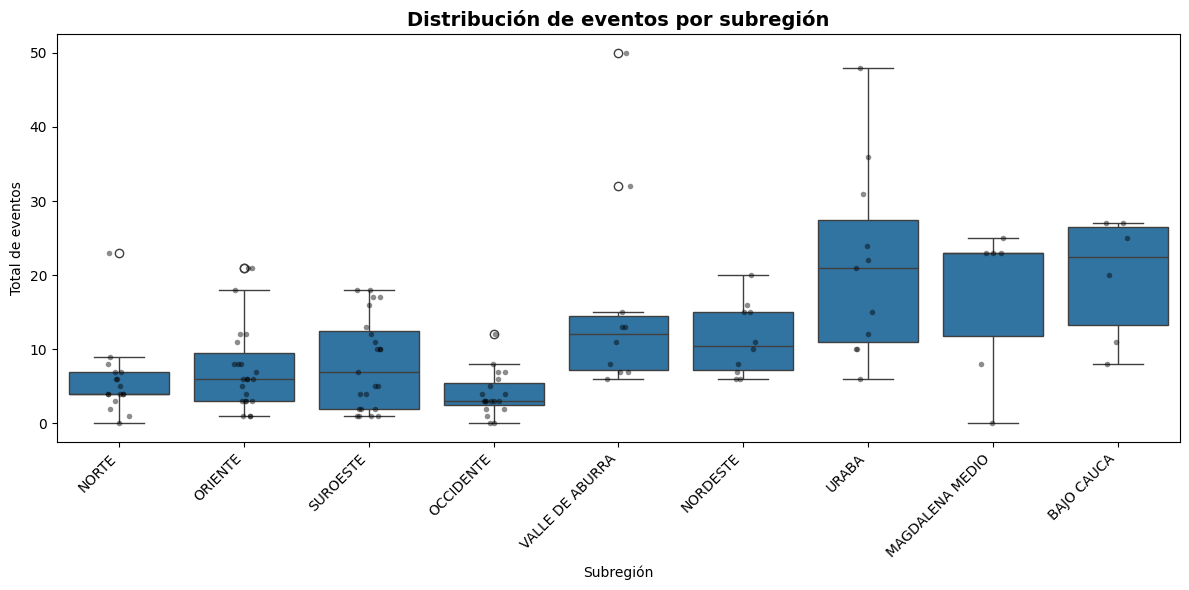

OLS REGIMES
RMSE         : 6.9636
MAE          : 4.9282
R²           : 0.4279
R² ajustado  : 0.4137


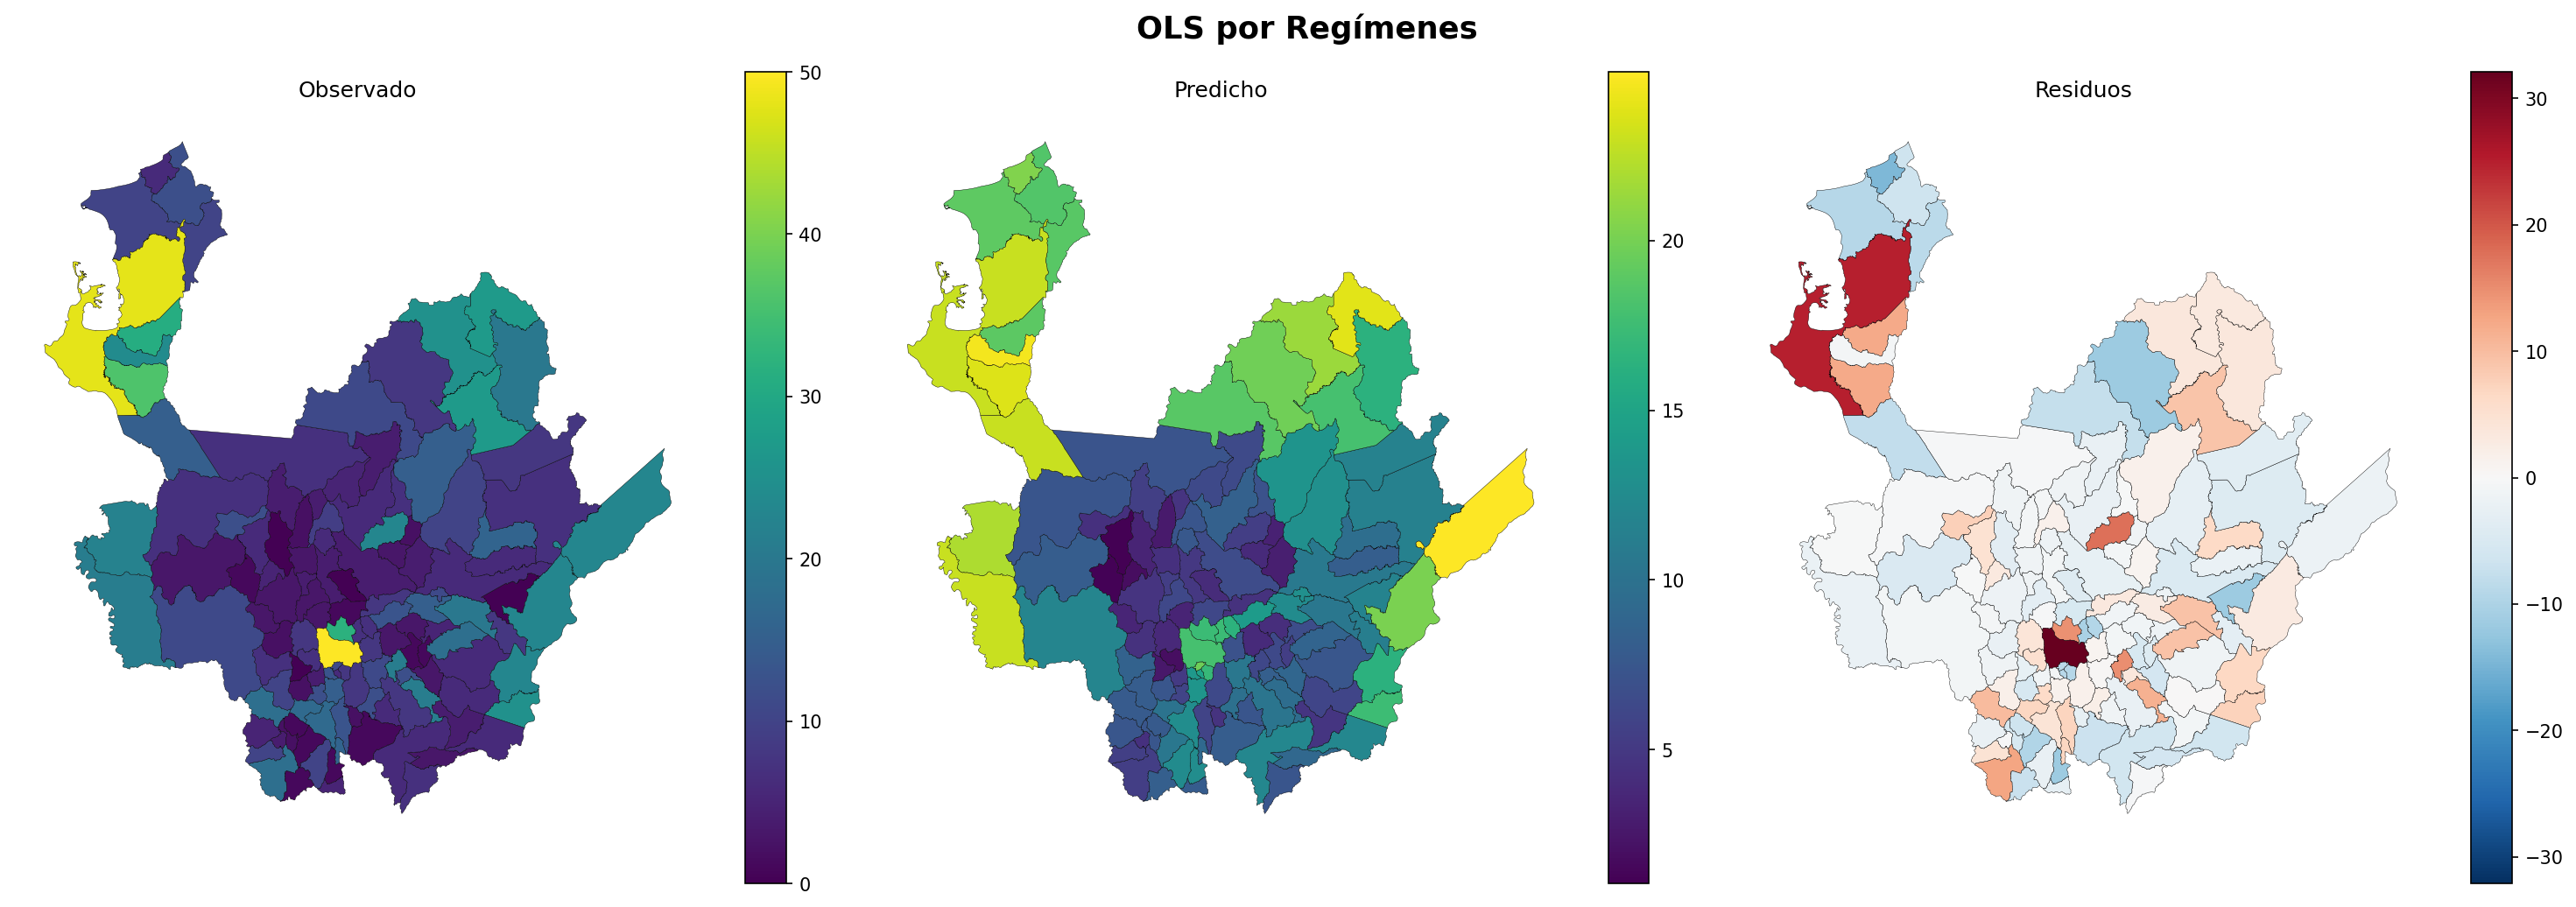

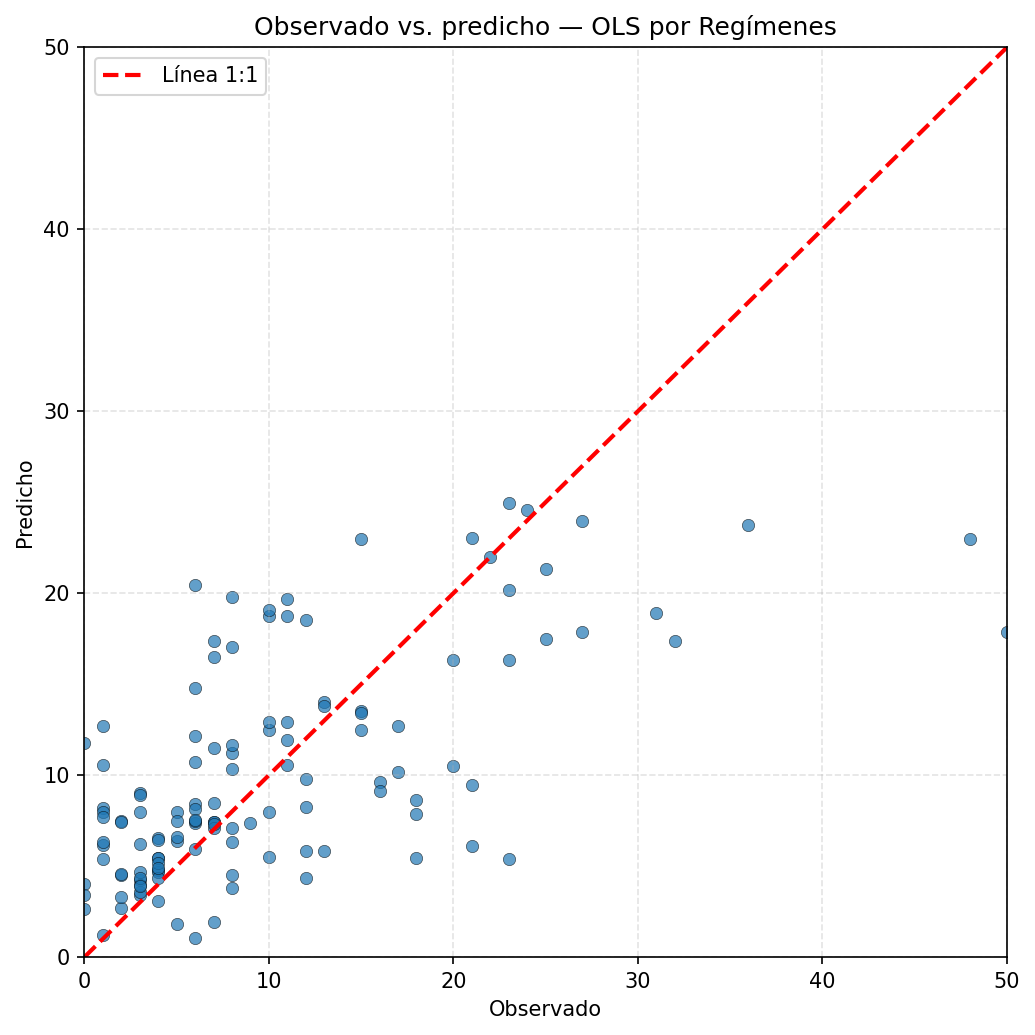

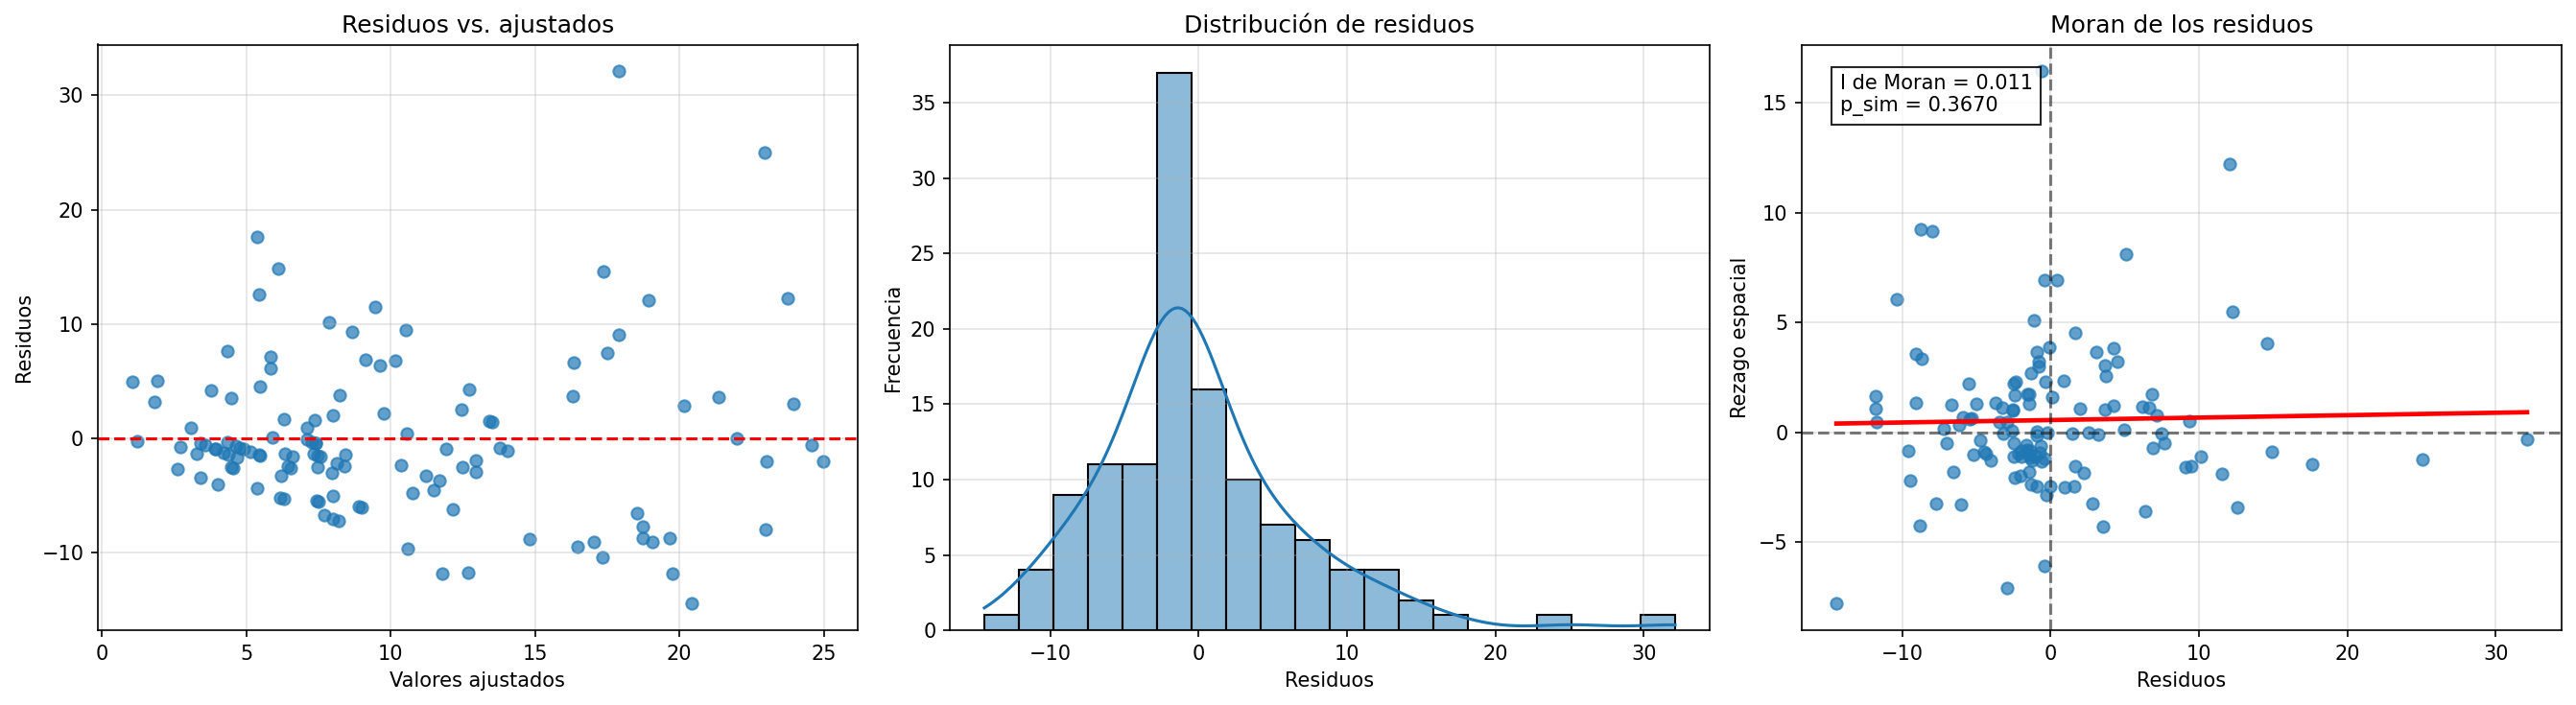

In [26]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import spreg
from sklearn.preprocessing import StandardScaler

# ==========================
# Variables explicativas
# ==========================
variables = [
    "Pend_mean",
    #"Elev_mean",
    #"LAI_mean",
    #"Curv_mean",
    #"TPI_mean",
    "TRI_mean",
    "Gradiente",
    #"Pend_std",
    #"Elev_std",
    #"LAI_std",
    #"Curv_std",
    #"TPI_std",
    #"TRI_std",
    #"Pend_cv",
    #"Elev_cv",
    #"LAI_cv",
    #"Curv_cv",
    #"TPI_cv",
    #"TRI_cv"
]

df = (
    gdf[["Tot_event", "Subregion"] + variables]
    .replace(-9999, np.nan)
    .dropna()
    .copy()
)

tabla_regimenes = (
    df["Subregion"]
    .value_counts()
    .rename_axis("Subregion")
    .reset_index(name="n")
)

display(tabla_regimenes)

scaler = StandardScaler()

df[variables] = scaler.fit_transform(df[variables])

y = df[["Tot_event"]].to_numpy(dtype=float)
X = df[variables].to_numpy(dtype=float)
regimenes = df["Subregion"].astype(str).tolist()

modelo_regimenes = spreg.OLS_Regimes(
    y=y,
    x=X,
    regimes=regimenes,

    constant_regi="many",
    cols2regi=[False] * len(variables),

    regime_err_sep=False,

    name_y="Tot_event",
    name_x=variables,
    name_regimes="Subregion",
    name_ds="Municipios"
)

print(modelo_regimenes.summary)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Subregion",
    y="Tot_event"
)

sns.stripplot(
    data=df,
    x="Subregion",
    y="Tot_event",
    color="black",
    alpha=0.45,
    size=4
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Subregión")
plt.ylabel("Total de eventos")
plt.title(
    "Distribución de eventos por subregión",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()
# ==========================
# Predicciones
# ==========================

y_obs = df["Tot_event"].to_numpy(dtype=float)

y_pred = modelo_regimenes.predy.flatten()

gdf["y_pred_reg"] = np.nan
gdf["Residuo_reg"] = np.nan

gdf.loc[df.index, "y_pred_reg"] = y_pred
gdf.loc[df.index, "Residuo_reg"] = y_obs - y_pred

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(
    mean_squared_error(y_obs, y_pred)
)

mae = mean_absolute_error(
    y_obs,
    y_pred
)

r2 = r2_score(
    y_obs,
    y_pred
)

n = len(y_obs)
p = X.shape[1]

r2_adj = 1 - (1-r2)*(n-1)/(n-p-1)

print("="*50)
print("OLS REGIMES")
print("="*50)
print(f"RMSE         : {rmse:.4f}")
print(f"MAE          : {mae:.4f}")
print(f"R²           : {r2:.4f}")
print(f"R² ajustado  : {r2_adj:.4f}")
print("="*50)


gdf_resultado_reg, moran_reg = graficas_statsmodels(
    gdf=gdf,
    indices=df.index,
    y_obs=y_obs,
    y_pred=y_pred,
    nombre_modelo="OLS por Regímenes"
)

from libpysal import weights
from esda import Moran

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np


def metricas_modelo(
    y_obs,
    y_pred,
    modelo=None,
    n_variables=None
):
    """
    Calcula métricas generales de ajuste para cualquier modelo.
    """

    y_obs = np.asarray(y_obs).flatten()
    y_pred = np.asarray(y_pred).flatten()

    rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
    mae = mean_absolute_error(y_obs, y_pred)
    r2 = r2_score(y_obs, y_pred)

    resultados = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    if n_variables is not None:

        n = len(y_obs)

        r2_adj = 1 - (1-r2)*(n-1)/(n-n_variables-1)

        resultados["R2_ajustado"] = r2_adj

    print("\n" + "="*60)
    print("MÉTRICAS DEL MODELO")
    print("="*60)

    for k,v in resultados.items():
        print(f"{k:20s}: {v:.4f}")

    if modelo is not None:

        if hasattr(modelo,"aic"):
            print(f"AIC                 : {modelo.aic:.3f}")

        if hasattr(modelo,"bic"):
            try:
                print(f"BIC                 : {modelo.bic:.3f}")
            except:
                pass

        if hasattr(modelo,"llf"):
            print(f"LogLik              : {modelo.llf:.3f}")

        if hasattr(modelo,"deviance"):
            print(f"Deviance            : {modelo.deviance:.3f}")

        if hasattr(modelo,"pearson_chi2"):
            print(f"Pearson Chi²        : {modelo.pearson_chi2:.3f}")

    print("="*60)

    return resultados

def graficas_modelo(
    gdf,
    indices,
    y_obs,
    y_pred,
    nombre_modelo=""
):

    gdf = gdf.copy()

    gdf["Observado"] = np.nan
    gdf["Predicho"] = np.nan

    gdf.loc[indices,"Observado"] = y_obs
    gdf.loc[indices,"Predicho"] = y_pred

    gdf["Residuo"] = (
        gdf["Observado"]
        - gdf["Predicho"]
    )

    ####################################################
    # MAPAS
    ####################################################

    fig,ax = plt.subplots(
        1,
        3,
        figsize=(18,6),
        dpi=150
    )

    vmax = max(
        gdf["Observado"].max(),
        gdf["Predicho"].max()
    )

    gdf.plot(
        column="Observado",
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        scheme="quantiles",
        k=5,
        legend=True,
        ax=ax[0]
    )

    ax[0].set_title("Observado")
    ax[0].set_axis_off()

    gdf.plot(
        column="Predicho",
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        scheme="quantiles",
        k=5,
        legend=True,
        ax=ax[1]
    )

    ax[1].set_title("Predicho")
    ax[1].set_axis_off()

    vmax_res = np.nanmax(np.abs(gdf["Residuo"]))

    gdf.plot(
        column="Residuo",
        cmap="RdBu_r",
        vmin=-vmax_res,
        vmax=vmax_res,
        legend=True,
        ax=ax[2]
    )

    ax[2].set_title("Residuos")
    ax[2].set_axis_off()

    plt.suptitle(nombre_modelo,fontsize=18,fontweight="bold")

    plt.tight_layout()

    plt.show()

    ####################################################
    # OBS VS PRED
    ####################################################

    fig,ax = plt.subplots(
        figsize=(7,7),
        dpi=150
    )

    ax.scatter(
        y_obs,
        y_pred,
        s=35,
        edgecolor="black",
        alpha=0.75
    )

    xmin=min(y_obs.min(),y_pred.min())
    xmax=max(y_obs.max(),y_pred.max())

    ax.plot(
        [xmin,xmax],
        [xmin,xmax],
        "r--",
        lw=2
    )

    ax.set_xlim(xmin,xmax)
    ax.set_ylim(xmin,xmax)

    ax.grid(ls="--",alpha=.4)

    ax.set_xlabel("Observado")
    ax.set_ylabel("Predicho")

    ax.set_title(
        f"Observado vs Predicho\n{nombre_modelo}"
    )

    plt.tight_layout()

    plt.show()

    ####################################################
    # MORAN
    ####################################################

    gdf_valid = gdf.loc[indices].copy()

    w = weights.Queen.from_dataframe(gdf_valid)

    w.transform="R"

    moran = Moran(
        gdf_valid["Residuo"],
        w
    )

    lag = weights.lag_spatial(
        w,
        gdf_valid["Residuo"]
    )

    fig,ax=plt.subplots(
        1,
        3,
        figsize=(18,5),
        dpi=150
    )

    ax[0].scatter(
        gdf_valid["Predicho"],
        gdf_valid["Residuo"],
        s=30
    )

    ax[0].axhline(
        0,
        ls="--",
        c="red"
    )

    ax[0].set_title("Residuos vs Ajustados")

    sns.histplot(
        gdf_valid["Residuo"],
        kde=True,
        ax=ax[1]
    )

    ax[1].set_title("Distribución")

    sns.regplot(
        x=gdf_valid["Residuo"],
        y=lag,
        ci=None,
        ax=ax[2],
        line_kws={"color":"red"}
    )

    ax[2].axhline(
        0,
        ls="--",
        c="black"
    )

    ax[2].axvline(
        0,
        ls="--",
        c="black"
    )

    ax[2].set_title("Moran")

    ax[2].text(
        .05,
        .95,
        f"I = {moran.I:.3f}\np = {moran.p_sim:.4f}",
        transform=ax[2].transAxes,
        va="top",
        bbox=dict(fc="white")
    )

    plt.tight_layout()

    plt.show()

    return gdf,moran

Bandwidth óptimo: 92.0
Número de vecinos usados: 92
Model type                                                         Gaussian
Number of observations:                                                 125
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            112.230
Log-likelihood:                                                    -170.632
AIC:                                                                351.264
AICc:                                                               353.976
BIC:                                                               -467.168
R2:                                                                   0.305
Adj. R2:                                                              0.282

Variable                              Est.         SE  t(Est/SE)    p-value
--------

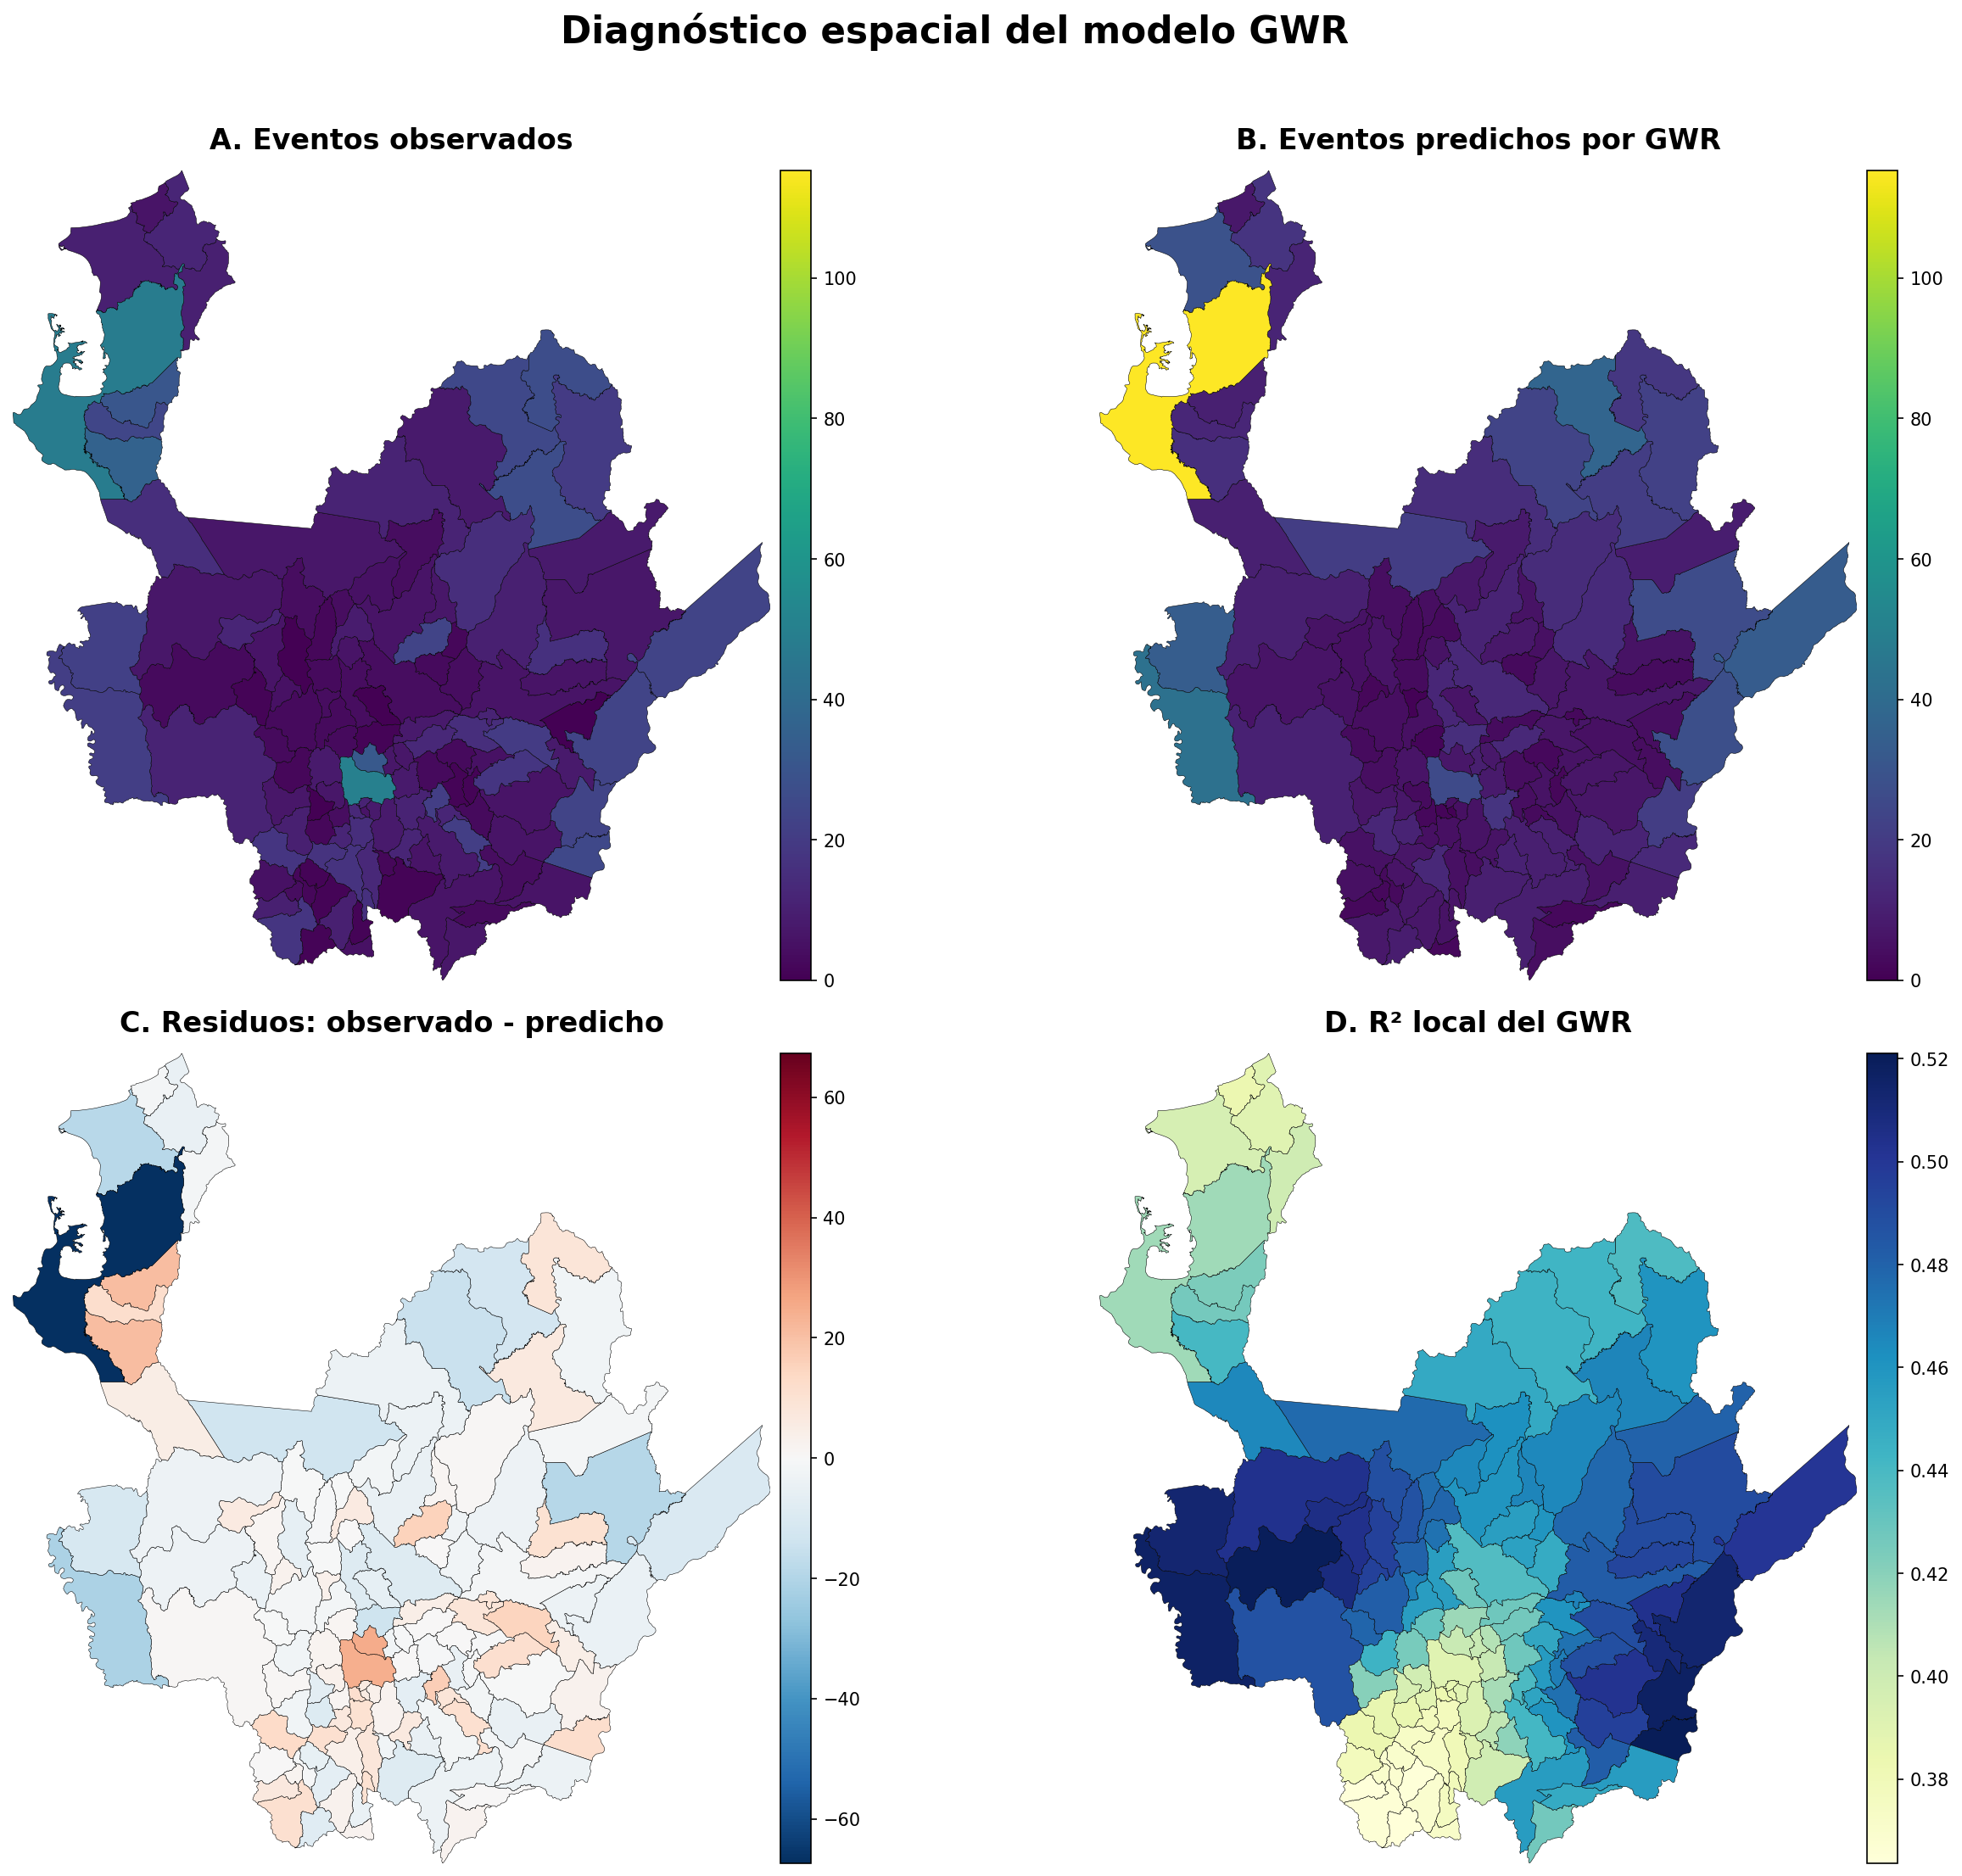

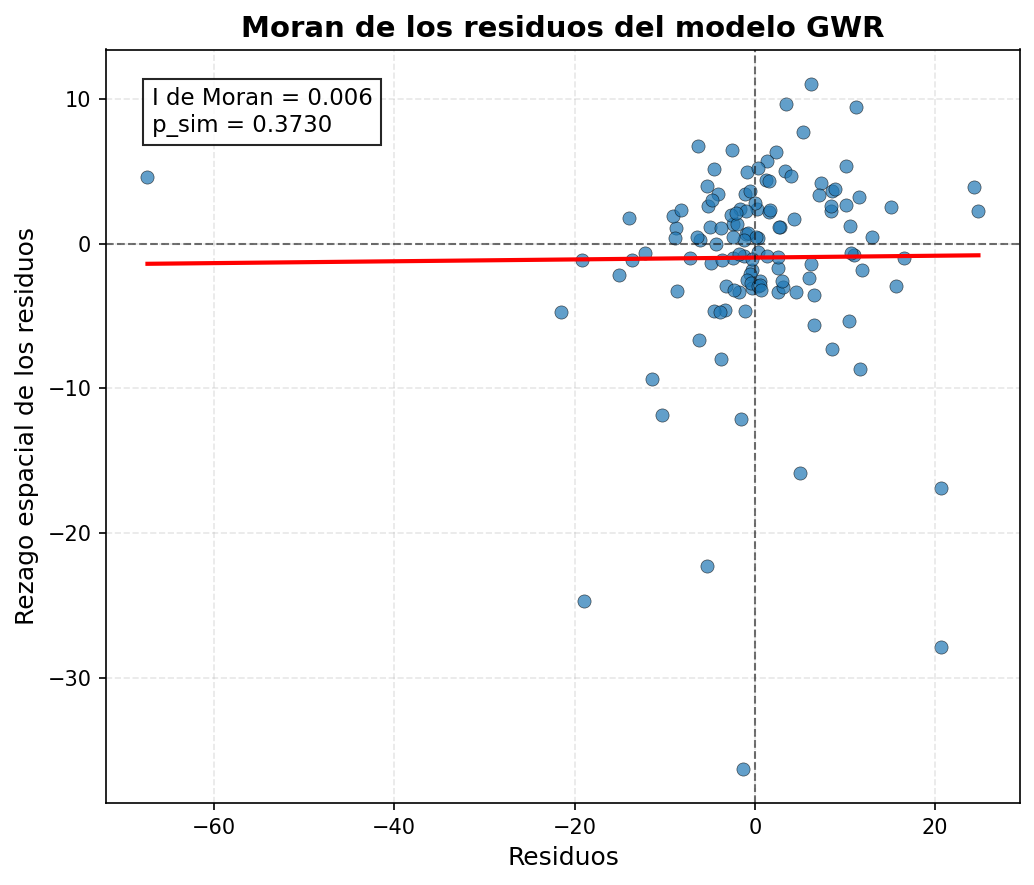

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

np.float = float

if gdf.crs.is_geographic:
    gdf_gwr = gdf.to_crs(gdf.estimate_utm_crs()).copy()
else:
    gdf_gwr = gdf.copy()

variables = variables = [
    "Pend_mean",
    "Elev_mean",
    "TRI_mean",
    "Gradiente",
]

df = (
    gdf_gwr[["Tot_event", "Area", "geometry"] + variables]
    .replace(-9999, np.nan)
    .dropna()
    .query("Area > 0")
    .copy()
)

# Respuesta ajustada por área
df["y_log"] = np.log(df["Tot_event"] + 1) - np.log(df["Area"])

y = df[["y_log"]].to_numpy()

coords = np.column_stack([
    df.geometry.centroid.x,
    df.geometry.centroid.y
])

X = StandardScaler().fit_transform(df[variables])

# Selección automática del bandwidth adaptativo
selector = Sel_BW(
    coords,
    y,
    X,
    kernel="bisquare",
    fixed=False
)

bw_optimo = selector.search(
    criterion="AICc"
)

print("Bandwidth óptimo:", bw_optimo)
print("Número de vecinos usados:", int(bw_optimo))

# Modelo GWR adaptativo
modelo_gwr = GWR(
    coords,
    y,
    X,
    bw=bw_optimo,
    kernel="bisquare",
    fixed=False
).fit()

print(modelo_gwr.summary())

import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx

from mpl_toolkits.axes_grid1 import make_axes_locatable


# =====================================================
# PREPARAR RESULTADOS DEL GWR
# =====================================================

gdf_plot = df.copy()

# Observado en escala original
gdf_plot["Observado"] = df["Tot_event"].to_numpy(dtype=float)

# Predicción en escala del modelo:
# log(Tot_event + 1) - log(Area)
pred_offset = modelo_gwr.predy.flatten()

# Volver a escala original de eventos
gdf_plot["Predicho"] = (
    np.exp(
        pred_offset
        + np.log(df["Area"].to_numpy(dtype=float))
    )
    - 1
)

# Evitar valores negativos por redondeo numérico
gdf_plot["Predicho"] = gdf_plot["Predicho"].clip(lower=0)

# Residuos en escala original
gdf_plot["Residuo"] = (
    gdf_plot["Observado"]
    - gdf_plot["Predicho"]
)

# R² local
gdf_plot["R2_local"] = modelo_gwr.localR2.flatten()


# =====================================================
# REPROYECTAR PARA MAPA BASE
# =====================================================

if gdf_plot.crs.is_geographic:
    gdf_mapa = gdf_plot.to_crs(epsg=3857)
else:
    gdf_mapa = gdf_plot.copy()


# =====================================================
# ESCALAS COMUNES
# =====================================================

vmin_eventos = min(
    gdf_mapa["Observado"].min(),
    gdf_mapa["Predicho"].min()
)

vmax_eventos = max(
    gdf_mapa["Observado"].max(),
    gdf_mapa["Predicho"].max()
)

vmax_residuo = np.nanmax(
    np.abs(gdf_mapa["Residuo"])
)

xmin, ymin, xmax, ymax = gdf_mapa.total_bounds




# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 15),
    dpi=150
)

axes = axes.flatten()


# -----------------------------------------------------
# 1. OBSERVADO
# -----------------------------------------------------

divider = make_axes_locatable(axes[0])
cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

gdf_mapa.plot(
    column="Observado",
    cmap="viridis",
    vmin=vmin_eventos,
    vmax=vmax_eventos,
    legend=True,
    cax=cax,
    edgecolor="black",
    linewidth=0.25,
    ax=axes[0],
    zorder=2
)

axes[0].set_title(
    "A. Eventos observados",
    fontsize=16,
    fontweight="bold",
    pad=12
)


# -----------------------------------------------------
# 2. PREDICHO
# -----------------------------------------------------

divider = make_axes_locatable(axes[1])
cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

gdf_mapa.plot(
    column="Predicho",
    cmap="viridis",
    vmin=vmin_eventos,
    vmax=vmax_eventos,
    legend=True,
    cax=cax,
    edgecolor="black",
    linewidth=0.25,
    ax=axes[1],
    zorder=2
)

axes[1].set_title(
    "B. Eventos predichos por GWR",
    fontsize=16,
    fontweight="bold",
    pad=12
)


# -----------------------------------------------------
# 3. RESIDUOS
# -----------------------------------------------------

divider = make_axes_locatable(axes[2])
cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

gdf_mapa.plot(
    column="Residuo",
    cmap="RdBu_r",
    vmin=-vmax_residuo,
    vmax=vmax_residuo,
    legend=True,
    cax=cax,
    edgecolor="black",
    linewidth=0.25,
    ax=axes[2],
    zorder=2
)

axes[2].set_title(
    "C. Residuos: observado - predicho",
    fontsize=16,
    fontweight="bold",
    pad=12
)


# -----------------------------------------------------
# 4. R² LOCAL
# -----------------------------------------------------

divider = make_axes_locatable(axes[3])
cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

gdf_mapa.plot(
    column="R2_local",
    cmap="YlGnBu",
    legend=True,
    cax=cax,
    edgecolor="black",
    linewidth=0.25,
    ax=axes[3],
    zorder=2
)

axes[3].set_title(
    "D. R² local del GWR",
    fontsize=16,
    fontweight="bold",
    pad=12
)


# =====================================================
# FORMATO COMÚN
# =====================================================

for ax in axes:

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_axis_off()

fig.suptitle(
    "Diagnóstico espacial del modelo GWR",
    fontsize=21,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

from libpysal import weights
from esda import Moran

# =====================================================
# MORAN DE LOS RESIDUOS DEL GWR
# =====================================================

# GeoDataFrame con las observaciones utilizadas en el modelo
gdf_residuos = gdf_plot.copy()

# Matriz Queen
w_residuos = weights.Queen.from_dataframe(
    gdf_residuos,
    use_index=True
)

w_residuos.transform = "R"

# Residuos
residuos_gwr = gdf_residuos["Residuo"].to_numpy(dtype=float)

# Rezago espacial de los residuos
lag_residuos_gwr = weights.lag_spatial(
    w_residuos,
    residuos_gwr
)

# Índice de Moran
moran_residuos_gwr = Moran(
    residuos_gwr,
    w_residuos,
    permutations=999
)

# =====================================================
# GRÁFICA DE MORAN
# =====================================================

fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=150
)

sns.regplot(
    x=residuos_gwr,
    y=lag_residuos_gwr,
    ci=None,
    ax=ax,
    scatter_kws={
        "s": 40,
        "alpha": 0.70,
        "edgecolor": "black",
        "linewidths": 0.3  # <-- Changed from "linewidth" to "linewidths"
    },
    line_kws={
        "color": "red",
        "linewidth": 2     # "linewidth" is perfectly fine here since line_kws plots a line, not a scatter
    }
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.55
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.55
)

ax.set_title(
    "Moran de los residuos del modelo GWR",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Residuos",
    fontsize=12
)

ax.set_ylabel(
    "Rezago espacial de los residuos",
    fontsize=12
)

ax.text(
    0.05,
    0.95,
    f"I de Moran = {moran_residuos_gwr.I:.3f}\n"
    f"p_sim = {moran_residuos_gwr.p_sim:.4f}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.85
    )
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()